In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models


# Подготовка данных CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

# Модель Учителя (ResNet-50)
teacher_model = models.resnet50(pretrained=True)
teacher_model.fc = nn.Linear(teacher_model.fc.in_features, 10)  # CIFAR-10 имеет 10 классов

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
teacher_model = teacher_model.to(device)

# Оптимизатор и критерий
optimizer = optim.Adam(teacher_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

100%|██████████| 170M/170M [00:04<00:00, 35.2MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


Epoch 1/10, Loss: 0.9310, Accuracy: 0.6861
Epoch 2/10, Loss: 0.6642, Accuracy: 0.7777
Epoch 3/10, Loss: 0.5157, Accuracy: 0.8292
Epoch 4/10, Loss: 0.4289, Accuracy: 0.8532
Epoch 5/10, Loss: 0.3267, Accuracy: 0.8888
Epoch 6/10, Loss: 0.2520, Accuracy: 0.9128
Epoch 7/10, Loss: 0.2016, Accuracy: 0.9311
Epoch 8/10, Loss: 0.1776, Accuracy: 0.9381
Epoch 9/10, Loss: 0.1483, Accuracy: 0.9501
Epoch 10/10, Loss: 0.3084, Accuracy: 0.8984


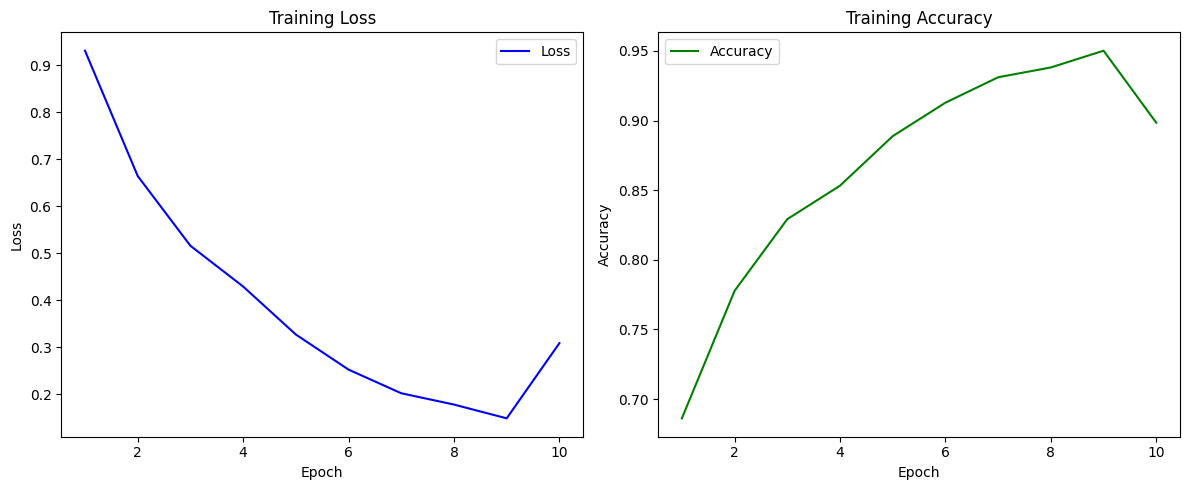

In [ ]:
import matplotlib.pyplot as plt

def train_teacher(model, train_loader, optimizer, criterion, device, epochs=10):
    """
    Обучает teacher model и визуализирует процесс обучения

    Args:
        model: модель для обучения
        train_loader: DataLoader с обучающими данными
        optimizer: оптимизатор
        criterion: функция потерь
        device: устройство (CPU/GPU)
        epochs: количество эпох обучения
    """
    # Переводим модель в режим обучения
    model.train()

    # Списки для сохранения истории метрик
    loss_history = []
    accuracy_history = []

    # Цикл обучения по эпохам
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Итерация по батчам данных
        for inputs, labels in train_loader:
            # Перемещаем данные на нужное устройство (GPU/CPU)
            inputs, labels = inputs.to(device), labels.to(device)

            # Обнуляем градиенты с предыдущей итерации
            optimizer.zero_grad()

            # Forward pass: получаем предсказания модели
            outputs = model(inputs)

            # Вычисляем значение функции потерь
            loss = criterion(outputs, labels)

            # Backward pass: вычисляем градиенты
            loss.backward()

            # Обновляем параметры модели
            optimizer.step()

            # Аккумулируем loss для статистики
            running_loss += loss.item()

            # Вычисляем accuracy
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        # Вычисляем средние метрики за эпоху
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = correct / total

        # Сохраняем метрики для визуализации
        loss_history.append(epoch_loss)
        accuracy_history.append(epoch_accuracy)

        # Выводим прогресс обучения
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

    # Визуализация кривых обучения
    if len(loss_history) == epochs and len(accuracy_history) == epochs:
        # Создаем фигуру с двумя subplots
        plt.figure(figsize=(12, 5))

        # График loss
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epochs + 1), loss_history, label="Loss", color="blue")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss")
        plt.legend()

        # График accuracy
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epochs + 1), accuracy_history, label="Accuracy", color="green")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Training Accuracy")
        plt.legend()

        # Оптимизируем расположение элементов на графике
        plt.tight_layout()

        # Показываем графики
        plt.show()
    else:
        # Сообщение об ошибке если размеры данных не совпадают
        print("Error: Length of loss_history or accuracy_history does not match the number of epochs!")

# Запускаем обучение teacher model
train_teacher(teacher_model, train_loader, optimizer, criterion, device)

## Модель Студента (ResNet-18)

In [ ]:
# Инициализация модели Student (ResNet-18)
student_model = models.resnet18(pretrained=False)
student_model.fc = nn.Linear(student_model.fc.in_features, 10)

student_model = student_model.to(device)

# Настройка оптимизатора и функции потерь
optimizer = optim.Adam(student_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/10, Loss: 1.3536, Accuracy: 0.5146
Epoch 2/10, Loss: 0.9717, Accuracy: 0.6548
Epoch 3/10, Loss: 0.7837, Accuracy: 0.7247
Epoch 4/10, Loss: 0.6567, Accuracy: 0.7707
Epoch 5/10, Loss: 0.5551, Accuracy: 0.8052
Epoch 6/10, Loss: 0.4577, Accuracy: 0.8405
Epoch 7/10, Loss: 0.3820, Accuracy: 0.8674
Epoch 8/10, Loss: 0.3064, Accuracy: 0.8924
Epoch 9/10, Loss: 0.2405, Accuracy: 0.9145
Epoch 10/10, Loss: 0.2048, Accuracy: 0.9284


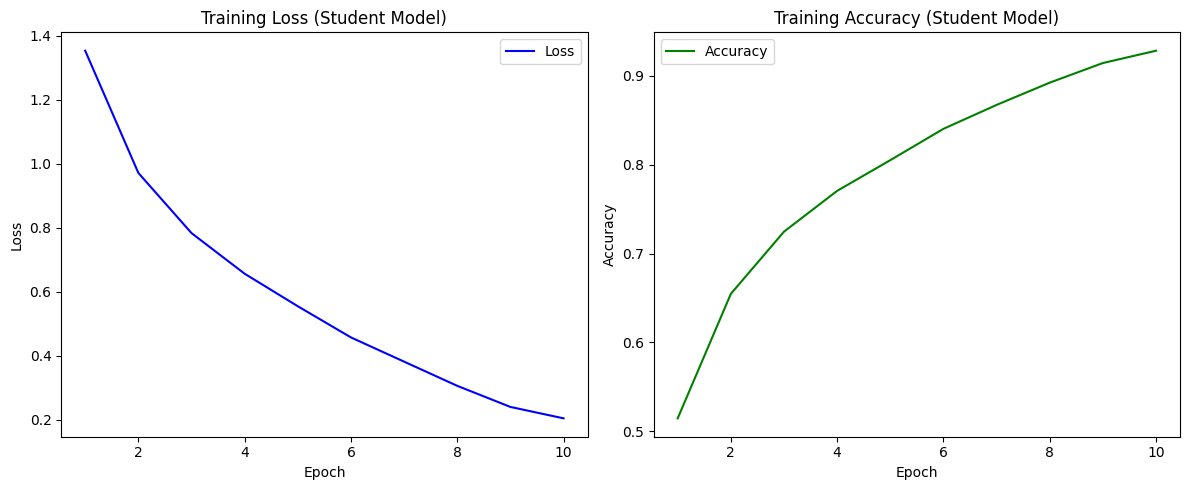

In [ ]:
# Обучение модели Студента

def train_student(model, train_loader, optimizer, criterion, device, epochs=10):
    """
    Обучает student model с мониторингом метрик и визуализацией прогресса
    """
    # Переводим модель в режим обучения
    model.train()

    # Инициализируем списки для отслеживания метрик
    loss_history = []
    accuracy_history = []

    # Цикл обучения по эпохам
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Итерация по батчам тренировочных данных
        for inputs, labels in train_loader:
            # Перемещаем данные на выбранное устройство (GPU/CPU)
            inputs, labels = inputs.to(device), labels.to(device)

            # Обнуляем градиенты с предыдущей итерации
            optimizer.zero_grad()

            # Forward pass: получаем предсказания модели
            outputs = model(inputs)

            # Вычисляем значение функции потерь
            loss = criterion(outputs, labels)

            # Backward pass: вычисляем градиенты
            loss.backward()

            # Обновляем веса модели
            optimizer.step()

            # Аккумулируем loss для статистики
            running_loss += loss.item()

            # Вычисляем accuracy для текущего батча
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        # Вычисляем средние метрики за эпоху
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = correct / total

        # Сохраняем метрики для последующей визуализации
        loss_history.append(epoch_loss)
        accuracy_history.append(epoch_accuracy)

        # Выводим прогресс обучения для текущей эпохи
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

    # Визуализация кривых обучения после завершения всех эпох
    if len(loss_history) == epochs and len(accuracy_history) == epochs:
        # Создаем фигуру с двумя subplots
        plt.figure(figsize=(12, 5))

        # График loss (левый subplot)
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epochs + 1), loss_history, label="Loss", color="blue")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss (Student Model)")
        plt.legend()

        # График accuracy (правый subplot)
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epochs + 1), accuracy_history, label="Accuracy", color="green")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Training Accuracy (Student Model)")
        plt.legend()

        # Оптимизируем расположение графиков
        plt.tight_layout()

        # Отображаем графики
        plt.show()
    else:
        # Сообщение об ошибке если данные не соответствуют ожиданиям
        print("Error: Length of loss_history or accuracy_history does not match the number of epochs!")

# Запуск обучения student model
train_student(student_model, train_loader, optimizer, criterion, device)

## Точность на тестовой выборке

In [ ]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Accuracy: {accuracy:.2f}%")

# Оценка моделей
evaluate_model(teacher_model, test_loader, device)
evaluate_model(student_model, test_loader, device)

Accuracy: 81.89%
Accuracy: 74.59%


In [ ]:
# Создаем обертку для извлечения промежуточных признаков из моделей
class FeatureExtractor(nn.Module):
    def __init__(self, model, layer_name):
        """
        Инициализация экстрактора признаков для заданного слоя модели

        Args:
            model: модель PyTorch для извлечения признаков
            layer_name: имя целевого слоя (например, "layer4.2")
        """
        super().__init__()
        self.model = model
        self.layer_name = layer_name
        self.outputs = None  # Здесь будут сохраняться извлеченные признаки

        # Регистрируем хук на указанном слое для захвата выходных активаций
        for name, module in self.model.named_modules():
            if name == self.layer_name:
                module.register_forward_hook(self.save_outputs)
                break  # Прерываем после нахождения целевого слоя

    def save_outputs(self, module, input, output):
        """
        Хук-функция, которая сохраняет выходные активации слоя
        """
        self.outputs = output

    def forward(self, x):
        """
        Прямой проход: пропускаем данные через модель и возвращаем признаки целевого слоя
        """
        _ = self.model(x)  # Выполняем прямой проход для активации хука
        return self.outputs

# Создаем экстракторы признаков для моделей teacher и student
teacher_feature_extractor = FeatureExtractor(teacher_model, "layer4.2")
student_feature_extractor = FeatureExtractor(student_model, "layer4.1")

print("Экстракторы признаков успешно созданы:")
print(f"Teacher: слой 'layer4.2'")
print(f"Student: слой 'layer4.1'")

Экстракторы признаков успешно созданы:
Teacher: слой 'layer4.2'
Student: слой 'layer4.1'


In [ ]:
class ResizeFeatures(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        # Сначала выравниваем вектор (если он 4D: Batch x Channels x H x W -> Batch x Features)
        x = x.view(x.size(0), -1)
        return self.fc(x)

teacher_resizer = ResizeFeatures(2048, 256)
student_resizer = ResizeFeatures(512, 256)
teacher_resizer = teacher_resizer.to(device)
student_resizer = student_resizer.to(device)

In [ ]:
import torch.nn.functional as F

def cosine_loss(student_features, teacher_features):
    return F.cosine_embedding_loss(
        student_features,
        teacher_features,
        torch.ones(student_features.size(0)).to(student_features.device)
    )

## Обучение студента с использованием знаний учителя


Начало процесса дистилляции знаний...
Количество эпох: 10
Epoch 1/10, Loss: 0.2511, Accuracy: 94.17%
Epoch 2/10, Loss: 0.2032, Accuracy: 95.19%
Epoch 3/10, Loss: 0.1803, Accuracy: 95.66%
Epoch 4/10, Loss: 0.1548, Accuracy: 96.20%
Epoch 5/10, Loss: 0.1419, Accuracy: 96.49%
Epoch 6/10, Loss: 0.1283, Accuracy: 96.90%
Epoch 7/10, Loss: 0.1206, Accuracy: 97.12%
Epoch 8/10, Loss: 0.1151, Accuracy: 97.23%
Epoch 9/10, Loss: 0.1062, Accuracy: 97.49%
Epoch 10/10, Loss: 0.1050, Accuracy: 97.53%

Завершение процесса дистилляции знаний


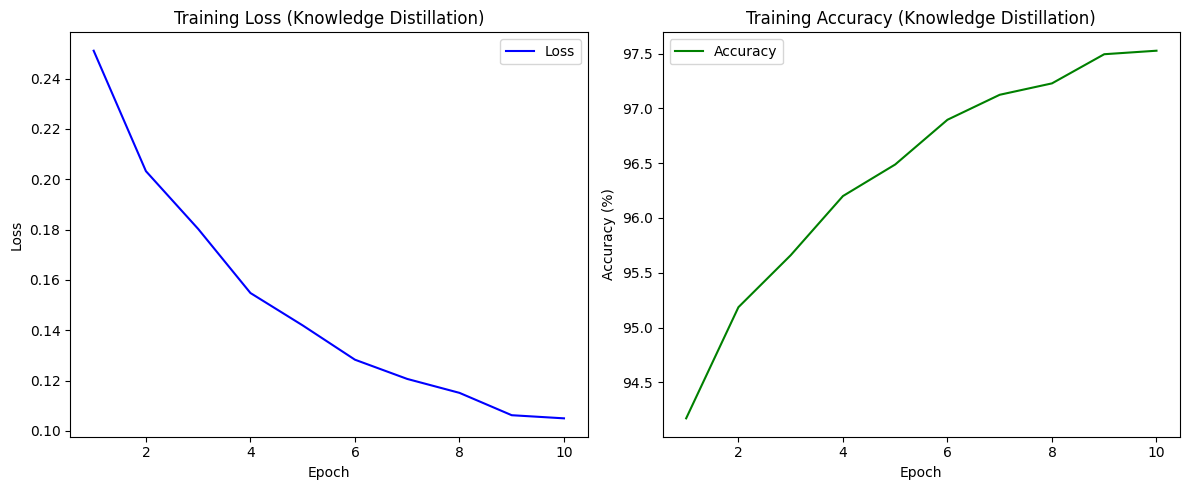


Визуализация метрик завершена


In [9]:
# Настройка параметров обучения
num_epochs = 10
teacher_model.eval()  # Переводим модель учителя в режим оценки (без градиентов)

# Инициализация списков для отслеживания метрик
loss_history = []
accuracy_history = []

print("Начало процесса дистилляции знаний...")
print(f"Количество эпох: {num_epochs}")

# Цикл обучения по эпохам
for epoch in range(num_epochs):
    student_model.train()  # Переводим модель студента в режим обучения
    running_loss = 0.0
    correct = 0
    total = 0

    # Итерация по батчам обучающих данных
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Извлечение признаков из моделей teacher и student
        with torch.no_grad():  # Отключаем градиенты для teacher модели
            teacher_features = teacher_feature_extractor(inputs)
        student_features = student_feature_extractor(inputs)

        # Применяем адаптеры размерности для согласования признаков
        teacher_features_resized = teacher_resizer(teacher_features.to(device))
        student_features_resized = student_resizer(student_features.to(device))

        # Вычисление компонентов функции потерь
        loss_cosine = cosine_loss(student_features_resized, teacher_features_resized)  # Косинусная потеря для дистилляции
        outputs = student_model(inputs)
        loss_ce = criterion(outputs, labels)  # Стандартная кросс-энтропия
        loss = loss_ce + 0.1 * loss_cosine  # Комбинированная потеря

        # Обратное распространение и оптимизация
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Сбор статистики для метрик
        running_loss += loss.item()

        # Расчет точности предсказаний
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Вычисление средних метрик за эпоху
    avg_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total

    # Сохранение метрик для визуализации
    loss_history.append(avg_loss)
    accuracy_history.append(accuracy)

    # Вывод прогресса обучения
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

print("\nЗавершение процесса дистилляции знаний")

# Визуализация результатов обучения
plt.figure(figsize=(12, 5))

# График функции потерь
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), loss_history, label="Loss", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Knowledge Distillation)")
plt.legend()

# График точности
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), accuracy_history, label="Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy (Knowledge Distillation)")
plt.legend()

plt.tight_layout()
plt.show()

print("\nВизуализация метрик завершена")

Добавляем обучаемый регрессор. Регрессором будет сверточным слоем (nn.Conv2d), который преобразует скрытые состояния Студента к размерности Учителя.



In [10]:
# Регрессор для трансформации пространства признаков студента в пространство учителя
class Regressor(nn.Module):
    """
    Простой сверточный регрессор для согласования размерностей признаков
    между student и teacher моделями
    """
    def __init__(self, input_channels, output_channels):
        """
        Инициализация регрессора

        Args:
            input_channels: количество входных каналов (student features)
            output_channels: количество выходных каналов (teacher features)
        """
        super().__init__()
        # 1x1 свертка для трансформации пространства признаков
        self.conv = nn.Conv2d(input_channels, output_channels,
                             kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        """
        Прямой проход: трансформирует признаки студента в пространство учителя

        Args:
            x: тензор признаков студента [batch_size, student_channels, H, W]

        Returns:
            трансформированные признаки [batch_size, teacher_channels, H, W]
        """
        return self.conv(x)


# Определение размерностей каналов для teacher и student моделей
teacher_channels = 2048  # Размерность признаков teacher модели
student_channels = 512   # Размерность признаков student модели

# Инициализация регрессора и перемещение на устройство
regressor = Regressor(student_channels, teacher_channels).to(device)
print(f"Регрессор инициализирован: {student_channels} -> {teacher_channels} каналов")

# Функция потерь для сравнения признаков
mse_loss = nn.MSELoss()

# Преобразование признаков и расчет потерь
teacher_features_resized = teacher_features.to(device)  # Признаки teacher модели
student_features_transformed = regressor(student_features.to(device))  # Трансформированные признаки student

# Расчет MSE потерь между признаками teacher и трансформированными признаками student
loss_mse = mse_loss(student_features_transformed, teacher_features_resized)

print(f"MSE loss между признаками: {loss_mse.item():.4f}")
print(f"Размерность teacher features: {teacher_features_resized.shape}")
print(f"Размерность student features (после регрессора): {student_features_transformed.shape}")

Регрессор инициализирован: 512 -> 2048 каналов
MSE loss между признаками: 0.7402
Размерность teacher features: torch.Size([80, 2048, 1, 1])
Размерность student features (после регрессора): torch.Size([80, 2048, 1, 1])


Начало обучения с дистилляцией знаний через MSE...
Количество эпох: 10
Epoch 1/10, Total Loss: 0.1214, MSE Loss: 0.7027, CE Loss: 0.0511
Epoch 2/10, Total Loss: 0.0900, MSE Loss: 0.5377, CE Loss: 0.0362
Epoch 3/10, Total Loss: 0.0922, MSE Loss: 0.4803, CE Loss: 0.0442
Epoch 4/10, Total Loss: 0.1026, MSE Loss: 0.4468, CE Loss: 0.0579
Epoch 5/10, Total Loss: 0.0896, MSE Loss: 0.4293, CE Loss: 0.0467
Epoch 6/10, Total Loss: 0.0904, MSE Loss: 0.4156, CE Loss: 0.0488
Epoch 7/10, Total Loss: 0.0887, MSE Loss: 0.4044, CE Loss: 0.0483
Epoch 8/10, Total Loss: 0.0864, MSE Loss: 0.3986, CE Loss: 0.0465
Epoch 9/10, Total Loss: 0.0797, MSE Loss: 0.3933, CE Loss: 0.0404
Epoch 10/10, Total Loss: 0.0773, MSE Loss: 0.3877, CE Loss: 0.0385

Обучение завершено. Визуализация метрик...


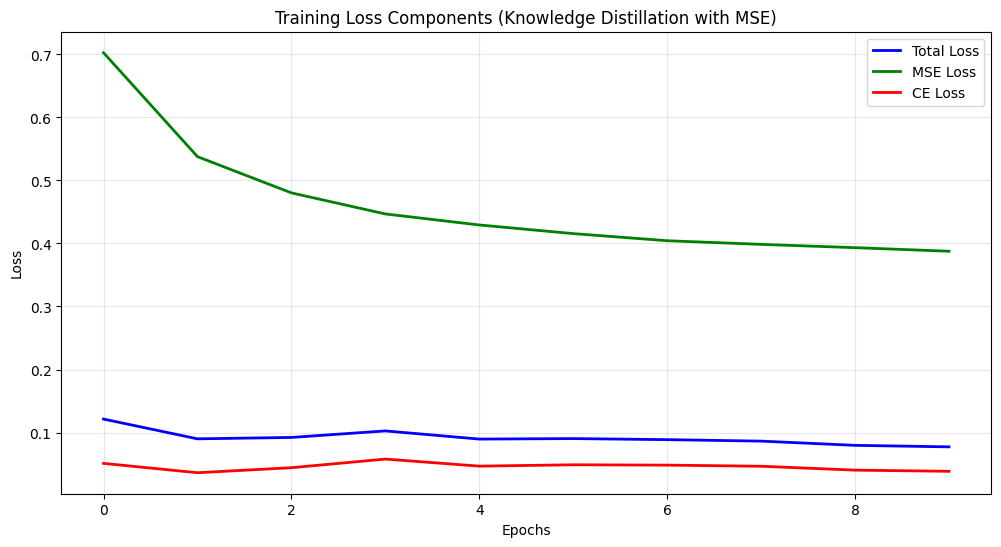

Визуализация завершена. Анализ компонентов потерь:
Финальный Total Loss: 0.0773
Финальный MSE Loss: 0.3877
Финальный CE Loss: 0.0385


In [11]:
# Инициализация списков для отслеживания различных компонентов потерь
total_loss_history = []
mse_loss_history = []
ce_loss_history = []

# Настройка параметров обучения
num_epochs = 10
print("Начало обучения с дистилляцией знаний через MSE...")
print(f"Количество эпох: {num_epochs}")

# Цикл обучения по эпохам
for epoch in range(num_epochs):
    # Переводим модели в режим обучения
    student_model.train()
    regressor.train()

    # Инициализация метрик для текущей эпохи
    running_loss = 0.0
    mse_loss_total = 0.0
    ce_loss_total = 0.0

    # Итерация по батчам обучающих данных
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Перемещение данных на устройство (GPU/CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Извлечение признаков из teacher модели (без градиентов)
        with torch.no_grad():
            teacher_features = teacher_feature_extractor(inputs)

        # Извлечение признаков из student модели
        student_features = student_feature_extractor(inputs)

        # Трансформация признаков student через регрессор
        student_features_transformed = regressor(student_features)

        # Вычисление компонентов функции потерь
        loss_ce = criterion(student_model(inputs), labels)  # Cross-Entropy loss для классификации
        loss_mse = mse_loss(student_features_transformed, teacher_features)  # MSE loss для дистилляции признаков

        # Комбинированная функция потерь с коэффициентом 0.1 для MSE компонента
        loss = loss_ce + 0.1 * loss_mse

        # Оптимизация: обнуление градиентов, обратное распространение, обновление весов
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Накопление статистики потерь для анализа
        running_loss += loss.item()
        mse_loss_total += loss_mse.item()
        ce_loss_total += loss_ce.item()

    # Расчет средних потерь за эпоху и сохранение в историю
    total_loss_history.append(running_loss / len(train_loader))
    mse_loss_history.append(mse_loss_total / len(train_loader))
    ce_loss_history.append(ce_loss_total / len(train_loader))

    # Вывод прогресса обучения с детализацией по компонентам потерь
    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Total Loss: {running_loss / len(train_loader):.4f}, "
          f"MSE Loss: {mse_loss_total / len(train_loader):.4f}, "
          f"CE Loss: {ce_loss_total / len(train_loader):.4f}")

print("\nОбучение завершено. Визуализация метрик...")

# Визуализация динамики потерь в процессе обучения
plt.figure(figsize=(12, 6))

# Построение графиков для всех компонентов потерь
plt.plot(total_loss_history, label='Total Loss', color='blue', linewidth=2)
plt.plot(mse_loss_history, label='MSE Loss', color='green', linewidth=2)
plt.plot(ce_loss_history, label='CE Loss', color='red', linewidth=2)

# Настройка оформления графика
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Components (Knowledge Distillation with MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Отображение графика
plt.show()

print("Визуализация завершена. Анализ компонентов потерь:")
print(f"Финальный Total Loss: {total_loss_history[-1]:.4f}")
print(f"Финальный MSE Loss: {mse_loss_history[-1]:.4f}")
print(f"Финальный CE Loss: {ce_loss_history[-1]:.4f}")